In [1]:
import torch
import torch.nn.functional as F
import matplotlib as plt
%matplotlib inline

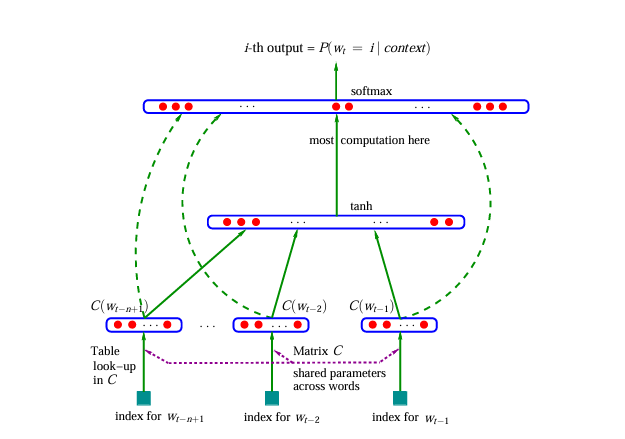
our goal here is to recreate this NN

In [2]:
# real in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# build the dataset
block_size = 3 # context lenght: how many characters do we take to predict the next one?
X,Y = [], [] # x is the input, y is the label
for w in words:
    #print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for  i in context), '---->', itos[ix])
        context = context[1:] + [ix] #crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [6]:
X.shape, X.dtype, Y.shape, Y.dtype # (torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)
# 1. (torch.Size([32, 3]) = a data set of 32 input examples, each with 3 char
# 2. torch.Size([32]) = a data set of 32 output label exmaples, one each for all the 32 input exmaples

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [7]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        ...,
        [26, 26, 25],
        [26, 25, 26],
        [25, 26, 24]])

In [8]:
Y

tensor([ 5, 13, 13,  ..., 26, 24,  0])

In [9]:
# this is after we ran the training, we are now doing hyper parameter traning 
# build the dataset

def build_dataset(words):
    block_size = 3 # context length: how many characters do we take to predict the next one?
    X, Y = [], []
    for w in words:

        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X) 
    Y = torch.tensor(Y) 
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42) 
random.shuffle(words)

n1 = int(0.8*len(words)) # 80% of the dataset
n2 = int(0.9*len(words)) # 90% of the dataset

Xtr, Ytr = build_dataset(words[:n1]) # 80% goes to training
Xdev, Ydev = build_dataset(words[n1:n2]) # n2 (90%) - n1 (80%) = 10% for validation
Xte, Yte = build_dataset(words[n2:]) #from 90% rest till word length = 10% for testing 

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [10]:
C = torch.randn((27, 2)) # so each of the 27 possible character will ahve 2 dimentional embeddings, we took these as like assumptions at the start 
# in the begining its intialized as random variables

In [11]:
C[5]

tensor([-0.5986,  0.3501])

In [12]:
# FYI:
F.one_hot(torch.tensor(5), num_classes=27) # see it will only encode when the input is a tensor or else it throws an error

tensor([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0])

In [13]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C # we actually arrive at the same result as C[5] be cuase this is BS
# all other number are 0 except the input and that we are trying to matrix mul and most of the data will be 0 and only that input will be left lol 
# what we just did and what we got was the embedding of the input 5 using the lookup embedding table C.
# rather than doing this mat mul we can simply call C[5] to get the embedding of that input as its the same shit

tensor([-0.5986,  0.3501])

In [14]:
emb = C[X] # here is what happended here, we embded our dataset with that embedding claiss of 2 embeds, 
emb.shape

torch.Size([228146, 3, 2])

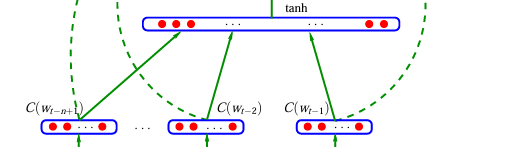

see that above tanh layer?! that is what we are tryna create here <br>
so we have 3 input (ie 3 char as input, we preduct the 4th) but each input comes with 2 sub imputs or to say 2 embeddings of each input so 6 total <br>
ie we will have 6 weights for each input type, 
and the no. of neuron inside of it can be chosen in random, lets say 100 for now

In [15]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [16]:
# emb @ W1 + b1 this is what we want to do but the shape won't match, emb is 3 space, w1 is 2

In [17]:
# so we need to concatenate 

# what are we doing below: 
# remember this? "# 1. (torch.Size([32, 3]) = a data set of 32 input examples, each with 3 char"?
# we want each char seperately, so we did 0, 1, 2, thgen : ie all of it on that dimention
# so it goes emb[all input, of 1st char, and all embedding of those inputs]
# emb[all input, of 2st char, and all embedding of those inputs], emb[all input, of 1st char, and all embedding of those inputs]
# 1 is the dim so we concatenated on the 
torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]], 1).shape 

torch.Size([228146, 6])

***A Better way to visualized this dim***

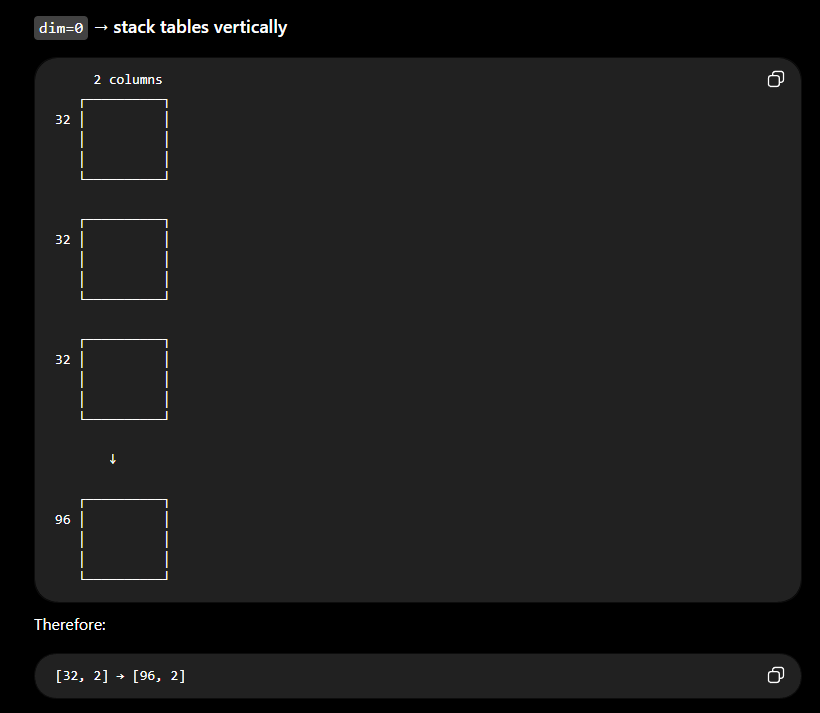 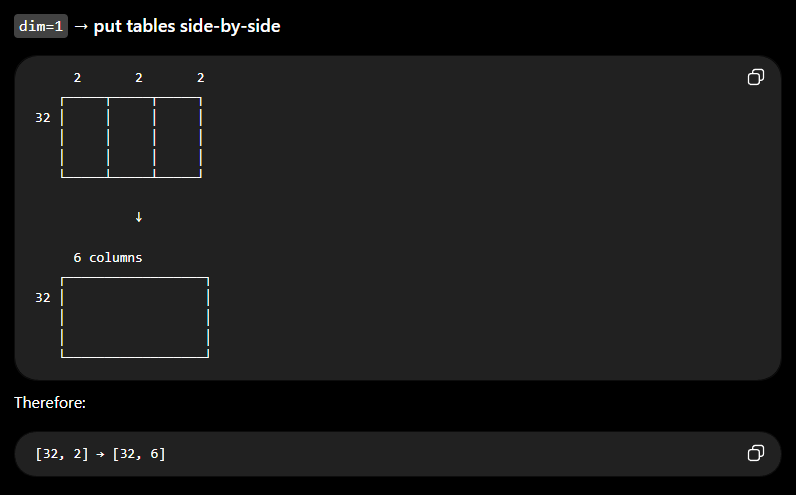

In [18]:
# now the generalized code for this 
# 'unbind' removes an rensor dimention and returns a slices tuple
torch.cat(torch.unbind(emb, 1), 1).shape # worst obtimization

# so this is what that unbind does:
# it removes a dim ie 1 from the [32, 3, 2] its the 3 char ie the index 1, 
# then (the rest of the 2 dim) it splits [32,2] by 3 as the layer that was removed was of size 2
# now cat adds them, as the 32 was same for all 3 char, but the 2 embedding were different so it create 6 embeding (2 for each char) for 32 times

torch.Size([228146, 6])

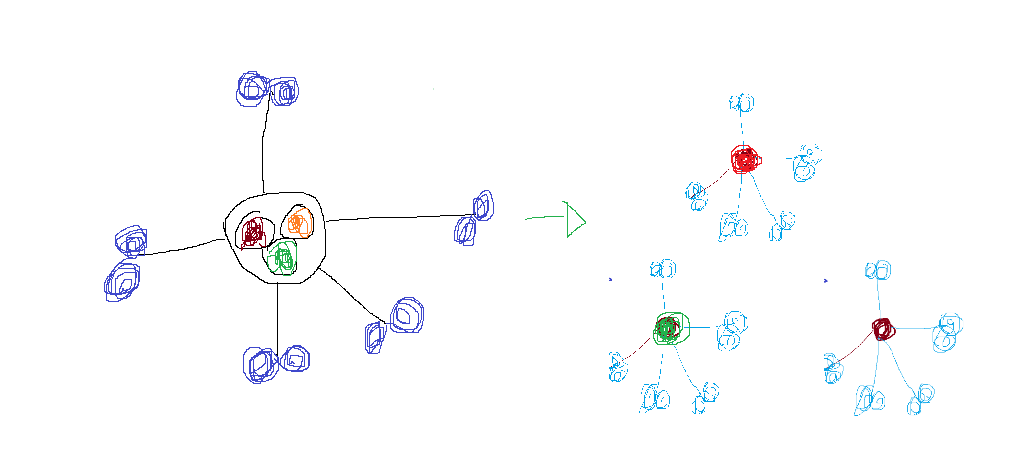

In [19]:
# another efficient way to do this is by using .view as this is extremely efficient

a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [20]:
a.shape

torch.Size([18])

In [21]:
# a bit of gymps into pytorch internals

a.storage # this tell that in memory the tensor are represented as 1 dim only 
# this is an importanat pytorch internal's info as .view can now mold it into any shape view as long as it multiplied to the size

<bound method Tensor.storage of tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])>

In [22]:
a1 = a.view(3,3,2).shape # we can make as 3*3*2 = 18
a2 = a.view(9,2).shape # we can do it as 9*2 = 18
#a21 = a.view(9,3).shape # this will throw an erro as 9*3 != 18 the size of the tensoe
print(a1, a2)

torch.Size([3, 3, 2]) torch.Size([9, 2])


In [23]:
emb.shape

torch.Size([228146, 3, 2])

In [ ]:
emb.view([32,6]) # that's it this simple! 
# this line will throw error if we use all the dataset or change it to word[:3] for this to work

In [ ]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # -1 means pytorch will choose that based on the it so its like x*6 = 192 (31*3*2) so it eventually will come as 32
# or in place of -1 we can do emb.shape[0] ie no. of element on first vector ie 32 (total combinations)

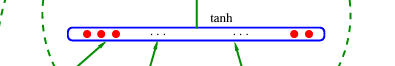

In [ ]:
h

In [ ]:
# FYI...

In [ ]:
(emb.view(-1, 6) @ W1).shape

In [ ]:
b1.shape

In [ ]:
# 32, 100
#   , 100
# so broadcast will will!

In [ ]:
# now creating weights and biases for layer 2 the output layer
W2 = torch.randn((100, 27)) # as the input to this layer was 100 neuron from prev layer, 
# and the otupt will be an probabilistic distribution of 27 char a to z
b2 = torch.randn(27) 

In [ ]:
# logits are the output

In [ ]:
logits = h @ W2 + b2

In [ ]:
counts = logits.exp()

In [ ]:
prob = counts / counts.sum(1, keepdims=True)

In [ ]:
prob.shape

In [ ]:
torch.arange(32)

In [ ]:
Y

In [ ]:
prob[torch.arange(32), Y] # the arrage give values from 0 to 31 that maps with y's 32 output dataset of 1 dim

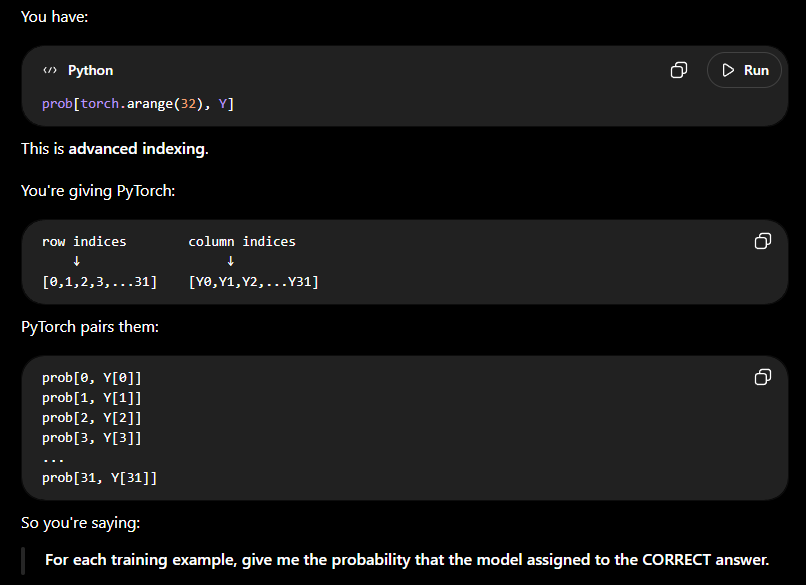

In [ ]:
# negative loss likely hood = loss
loss = -prob[torch.arange(32), Y].log().mean()
loss

In [ ]:
# ------------ now made respectable :) ------------

In [25]:
X.shape, Y.shape # dataset

(torch.Size([228146, 3]), torch.Size([228146]))

In [26]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2] # we clustered all the parameters into 1 list of sub lists each with different size 

In [27]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

**why to use pytorch inbuild loss function cross entry rather than our own custom one**

In [28]:
logits = torch.tensor([-100, -3, 0,100])
counts = logits.exp()
probs = counts / counts.sum()
print(probs)
print(counts) # what happen is at first we pass in a very small ammount -100 that though .exp() gave some very small numbers 3.7835e-44, 
# but then we give it a very high number like 100 and now e^100 is something that is out of its range, so it goes inf 
# and these are the type of error we can revent by using corss entropy

tensor([0., 0., 0., nan])
tensor([3.7835e-44, 4.9787e-02, 1.0000e+00,        inf])


In [29]:
# the way pytorch solve this is to add offset it by any custom number
logits = torch.tensor([-5, -3, 0,100]) -100 #it calculates the max number and it subtract it
# so now that very high e^100 is now offsetted by -100 and that will now behave well!
counts = logits.exp()
probs = counts / counts.sum()
print(probs)
print(counts)

tensor([0.0000e+00, 1.4013e-45, 3.7835e-44, 1.0000e+00])
tensor([0.0000e+00, 1.4013e-45, 3.7835e-44, 1.0000e+00])


In [30]:
#counts = logits.exp()
#prob = counts / counts.sum(1, keepdims=True)
#loss = -prob[torch.arange(32), Y].log().mean()

# we acutally use the cross entropy for production and not make our own loss calculation as this is much better peforming internally
# because it runned in a 'fused kernel' and its numerically well behaved
# also the froward pass and the backward pass can be much more efficient

In [31]:
for p in parameters:
    p.requires_grad = True

**how to determine the learning reat**

In [ ]:
# Lre: learning-rate exponent || Lrs = Learning Rates
lre = torch.linspace(-3, 0, 1000) # (start, end, step count)
lrs = 10**lre # 10^x ie: 10^-3 = 0.001 and 10^0 = 1, so its essentially -.001 to 1 of 1000 steps
# then why we did n't do torch.linspace(-0.001, 1, 1000)? as this is AP, linear +100x difference between numbers like.001, 0.112. 0.223 ... ie differnce of +111
# but when we do logarithmic diffrence we get something like 0.002, 0.005, 0.010, 0.022 ... ie differnece is x2.15 (GP gemetric progression alike)
# whe we want log one "Because learning rates usually matter by orders of magnitude." ie
# we care more about testing at 0.001. 0.01. 0.1 1.0 10.0 than 0.001, 0.101, 0.201 and so one, as from 0.101 till 0.901 the order of magniture is very manute and same
lrs

In [38]:
# this whole thing is fucked alright?! it will kill the workflow, please don't run this!

import time

t = time.time()

lri=[]
lossi=[]
for i in range(1000): # before it was for _ in range(1000)
    # Forward pass
    emb = C[X] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    
    loss = F.cross_entropy(logits, Y) 
    #print(loss.item()) # loss at each epoch
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #update
    #lr = lrs[i]
    # from the graph we can see that the best lre is somewhere around -0.49 or -0.5 ie 10^-0.5 = 0.316
    #lr = 0.316 # now we fix the lr!
    lr = 0.316 # now that we ran in the best lr we found, lets do lr decay, basically decreasing it by an exponent and run again to get even better loss
    # before decay it was 2.431, after its: 2.427 :( not much lol
    for p in parameters:
        #p.data += -0.001 * p.grad
        p.data += -lr * p.grad

    # track Lr to find the optimal point
    #lri.append(lr)
    #lri.append(lre[i])# take exponet value help to visualize better
    #lossi.append(loss.item())

print(loss.item()) # final loss
print(f"time taken for execution: {time.time() -t}")

2.4905474185943604
time taken for execution: 316.22451066970825


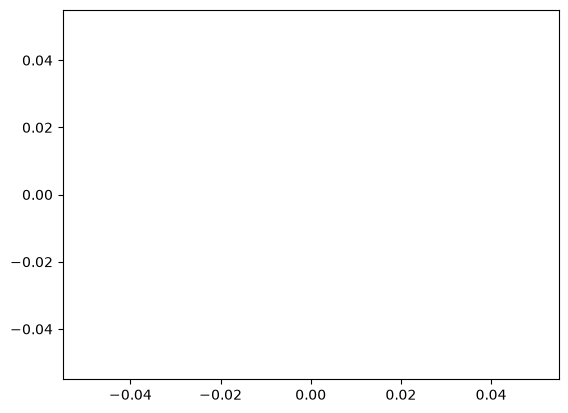

In [39]:
import matplotlib.pyplot as plt
plt.plot(lri, lossi)

In [35]:
logits.max(1) # max value at 1st index column

torch.return_types.max(
values=tensor([3.5701, 3.3970, 2.3829,  ..., 2.5717, 1.8311, 3.8269],
       grad_fn=<MaxBackward0>),
indices=tensor([1, 1, 1,  ..., 0, 0, 0]))

In [ ]:
Y

In [ ]:
# here is the reason why it doesn't reach 0% loss as there are dataset where ... => a ... => s and so on, now the same input gave different output
# this can't be overfitten or remembered that's why its not 0
# and if we remove those then our model will over fit (bad by design ofc but the loss will be 0)

In [ ]:
emb = C[X]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2+b2
loss = F.cross_entropy(logits,Y)
loss

In [ ]:
# training split, dev/validation split, test split
# 80%, 10%, 10%

In [80]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)# we increase the embedding dim from 2 to 10
W1 = torch.randn((30, 200), generator=g)# we increased the neuron size from 100 -> 300, input 6 -> 30, 3*10=3- 
b1 = torch.randn(200, generator=g) # the biases also increased
W2 = torch.randn((200, 27), generator=g)  # as well as the input weights for the last layer
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]

In [81]:
sum(p.nelement() for p in parameters) # no. of parameters in total

11897

In [82]:
for p in parameters:
    p.requires_grad = True

In [83]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [90]:
lri = []
lossi = []
stepi = []

In [105]:
# this is after creating the new train test split dataset
#for i in range(50000):
for i in range(200000): # now for the big daddy trianing, do this after many iteration of tweeking, which we got it down to 2.1

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # forward pass
    emb = C[Xtr[ix]] # (32, 3, 2) beofre it was C[X]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100), these -1,30 are called as magic numbers and in prod they should not be hardcoded like this
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    #print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    #lr = lrs[i]
    #lr = 0.01
    lr = 0.01 if i<100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    stepi.append(i) # keep track of no of steps
    lossi.append(loss.log10().item()) # we are besically getting the log loss, better viz as log squashes them into a log plane

print(loss.item())

2.011641263961792


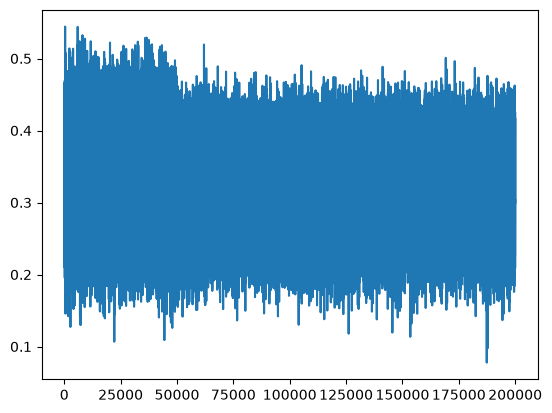

In [106]:
plt.plot(stepi,lossi)

In [107]:
# evaluating the loss against the training dataset
emb = C[Xtr]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2+b2
loss = F.cross_entropy(logits,Ytr)
loss

tensor(2.1089, grad_fn=<NllLossBackward0>)

In [108]:
# evaluating the loss against the validation dataset
emb = C[Xdev]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2+b2
loss = F.cross_entropy(logits,Ydev)
loss

tensor(2.1538, grad_fn=<NllLossBackward0>)

In [109]:
# here the training and the validatoin dataset's erro rate are almost the same at 2.3679 
# this means that we are not overfitting
# this typically means underfitting, and smaller size of dataset

In [110]:
# remember the initial embedding vetor? it was of 2 embeddings only, and that could be a suspected bottleneck

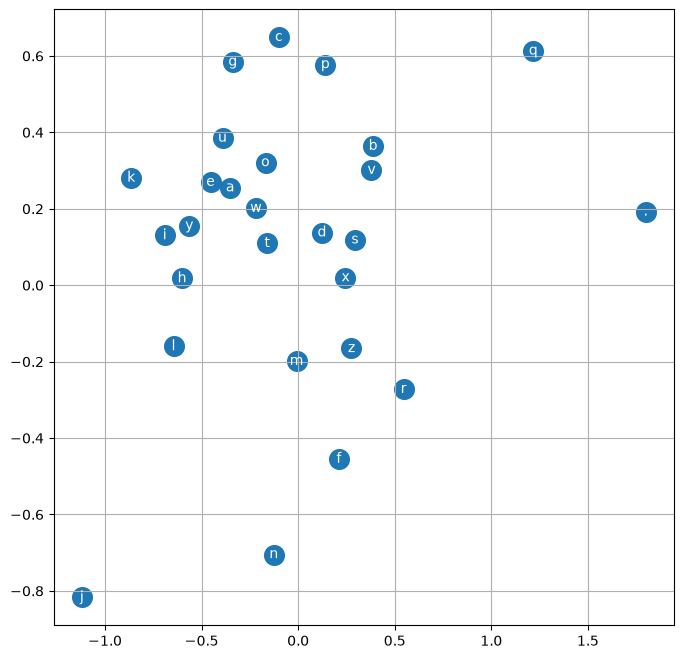

In [111]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

**now how do we imporve it further?**

In [112]:
# tweek every bit of input, the no of charcter as input (we had taken 3, take 4, 2, 5 etc)

In [113]:
# change the embedding diamention (right now its set at 10 before it was 2, change it to 20 maybe or 6)

In [114]:
# then tweek the middle layers, total neuron etc

In [115]:
# change the trainig loop its at 200k now

In [116]:
# change the Lrs, the decay after Lrs

In [117]:
# change the batch size too

In [118]:
# Sample from the model ---- 

g = torch.Generator().manual_seed(2147483647 + 10)
for _ in range(20): # this means it will generate 20 names
    out = [] # these are the character wise indeces that will be product, around ~4-6 per loop ie ~4-6 char = 1 word
    context = [0] * block_size # initialize with all '.' ie 0 here, btw the block size was 3 ie context = [0,0,0]
    while True:
        # remember c was: C = torch.randn((27, 10), generator=g), ie 27 char and 10 embedding dim
        emb = C[torch.tensor([context])] # (1, block_size,d), this is like saying give me row [0,0,0] of C and as context is 1,3, and c is 27, 10
        # so its emb = [[C[0], C[0], C[0]]] # which is, 1 big tensor, has 3 tensor and each has 10 embedding tensor, so its (1,3,10)
        #convert current context into tensor so now its [[0,0,0]] or (1,3)
        h = torch.tanh(emb.view(1,-1) @ W1 + b1) # now we want to conver it into 2 dim, and first is 1, and for 2nd we did -1 ie system decide
        # so the pytorch did 30, ie (1,3,10) = (1,30) which is right as remember that rule mul should be the same number, 1*3*10 = 1*30 right!!
        # ie 3 context * 10 embedding each so now its [C[0], C[0], C[0]] <= ie we remove 1 layer of [] ie an dim removed!!
        # so what is this h? its the output of our hidden layer!
        logits = h @ W2 + b2 # basically we are running the final layer of the network, that gives the otuput, thats why its w2,b2 not w1,b1
        probs = torch.softmax(logits, dim=1) # converted into probabilistic distribution from -1 to 1 with sum = 1.0
        ix = torch.multinomial(probs, num_sample=1, generator=g).item() # after getting all the probability of each of the 27 char appearing next
        # we are not choosing the next with the prob that is the highest, we are choosing it randomly
        # but here the randomly are weighted, and that weights are the probability we got from the softmax for each of the 27 char
        # see if a character m as highest priority, the weighted random pull will also be this only max of the time but not 100% of the time
        # this stops the model from becoming deterministic and boring, 
        # this might look wrong like why are we not choosing the highest priority one? that might be the correct one?
        # but the thing is that, the model is not giving the right next work, its giving the most possible one.
        # where that highest priority fail?, man, mat, may, here ma.. next word could be n t y with 33% probabiliyt, but if we choose highest it will always return man
        # so this will destroy the diversity that exists in the training distribution
        context = context[1:] + [ix] # now this adds the character to the context, em, emm, emma ... like this
        out.append(ix) # save the generated character
        if ix ==0: # ie remember 0 = '.' in our sense, so when it reaches 0 at the end means the char has ended for the word
            break
    print(''.join(itos[i] for i in out))# joing and print each word, and repeat

'''
but now what is the difference between here and there? here also agian we are doing the same forward pass trainig, then what is the use of 
that much of training?, see, at the begining we too the weights w1,w2.. and the biases b1,b2.. ar random and our whole goal was to run this
forward backward and udpate wieghts and baises loop a gazillion time to conver the random initializatino of w and b into proper learnign weights

now that weights will be used one again in multi loop, each looop 1 word like that; (but  no backprop as we agre not udpate the w & b any further) to get the final answer

Training = find good parameters (weights, biases, etc.).
Inference = run the learned function forward once on new input to get the final generation (this is the generation that eats up our GPU
when we "run a pretrained model".
'''

SyntaxError: invalid syntax (2976037747.py, line 12)

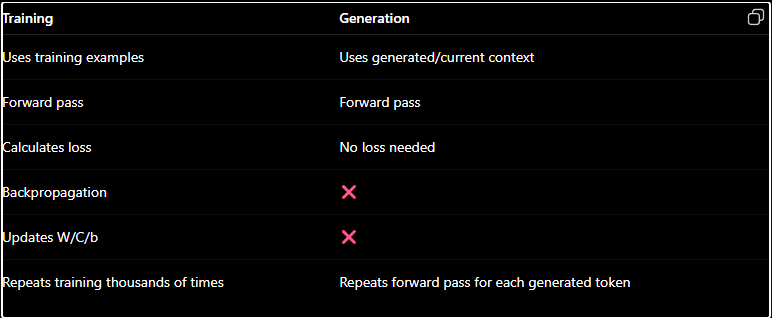